## Performance comparison of triangular matrix inverse

> The goal is to understand the "peak performance" of Ascend for AIV / AIC triangular inverse methods.

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2.
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["s", "^", "v", "<", ">", "o", "X"]

_SNS_PARAMS = {"hue":'inverse_type', "style":'inverse_type', "markers":_MARKERS, "dashes":True}


In [11]:
# Select plot parameters

chunk_size = 128

In [12]:
def add_stats_siso(df, nbytes_out_dtype: int):
    df["size"] = df["numel"]
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp32": 4, "fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [13]:
PREFIX_PATH = "../.."

df = pd.read_csv(f"{PREFIX_PATH}/bench_results_solve_tril_{chunk_size}.csv")
add_stats_siso(df, 4)

B, T, H = df["B"].unique()[0], df["T"].unique()[0], df["H"].unique()[0]

In [14]:
df.head()

,inverse_type,dtype,B,T,H,numel,chunk_size,time_us,size,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,torch-eager,fp16,32,512,4,8388608,128,21227,8388608,2,50331648,0.395186,2.371115
1,torch-eager,fp16,32,1024,4,16777216,128,36132,16777216,2,100663296,0.464331,2.785987
2,torch-eager,fp16,32,2048,4,33554432,128,65857,33554432,2,201326592,0.509504,3.057026
3,torch-eager,fp16,32,4096,4,67108864,128,133935,67108864,2,402653184,0.501055,3.006333
4,torch-eager,fp16,32,8192,4,134217728,128,302465,134217728,2,805306368,0.443746,2.662478


## Paper plots

/tmp/ipykernel_338172/2446363715.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_338172/2446363715.py:8: UserWarning: The markers list has more values (7) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)


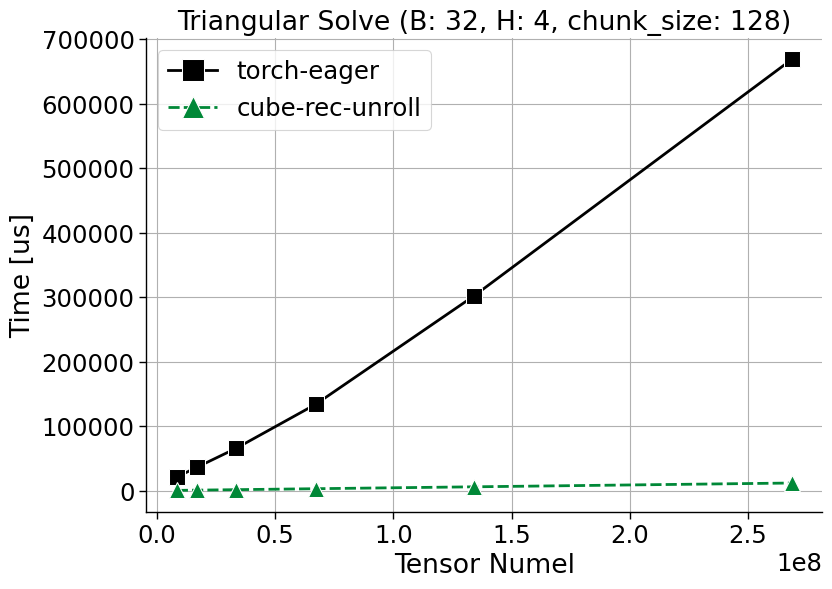

<Figure size 870x627 with 0 Axes>

In [15]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Triangular Solve (B: {B}, H: {H}, chunk_size: {chunk_size})")
ax.set_xlabel("Tensor Numel")
ax.set_ylabel("Time [us]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/tri_inv_time_us.png")
plt.show()
plt.clf()


/tmp/ipykernel_338172/4006480999.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_338172/4006480999.py:8: UserWarning: The markers list has more values (7) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


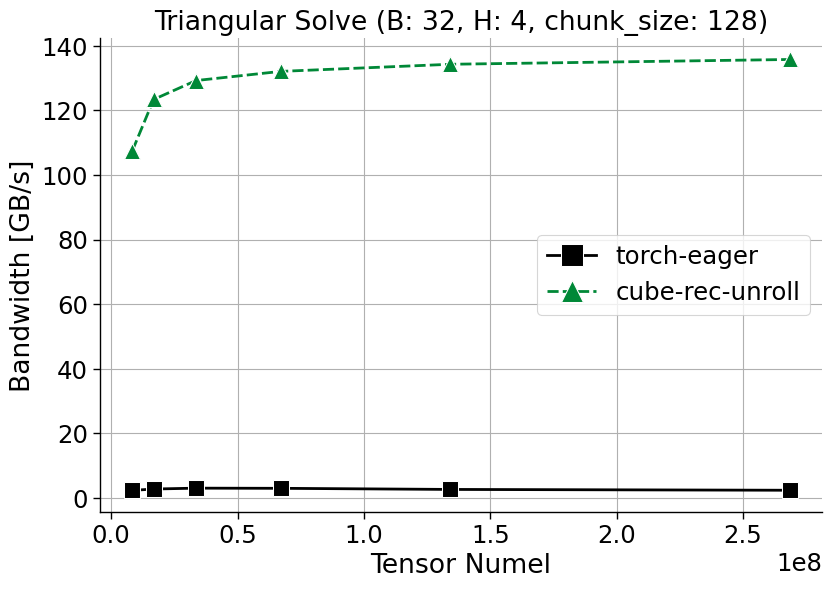

<Figure size 870x627 with 0 Axes>

In [16]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Triangular Solve (B: {B}, H: {H}, chunk_size: {chunk_size})")
ax.set_xlabel("Tensor Numel")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/tri_inv_bw_gbps.png")
plt.show()
plt.clf()

## Compute Analysis of Triangular Inverse Kernels

In [ ]:
import math

def algo_flops(inverse_method: str, matrix_size: int, batch_size: int):
    inv_num_ops = 2 * matrix_size ** 3 # 2 for one addition/multiplication and O(matrix_size^3) for matrix multiplication.
    if inverse_method == "torch-eager":
        return inv_num_ops * batch_size
    elif inverse_method == "column-sweep":
        return inv_num_ops * batch_size
    elif inverse_method == "triton":
        return inv_num_ops * batch_size # TODO(anastasios): this is wrong, we need to account for the fact that the triton implementation is recursive and has a different number of operations.
    elif inverse_method == "cube-rec-unroll":
        return inv_num_ops * (16 + math.log2(matrix_size/16) * 4) * batch_size
    else:
        raise ValueError(f"Unsupported inverse method: {inverse_method}")
    
df["ops"] = df.apply(lambda row: algo_flops(row["inverse_type"], row["chunk_size"], row["numel"] // (row["chunk_size"] ** 2)), axis=1)
df["gflops"] = (df["ops"] / 1e9) / (df["time_us"] / 1e6)

/tmp/ipykernel_338172/267475844.py:1: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gflops', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_338172/267475844.py:1: UserWarning: The markers list has more values (7) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gflops', palette=palette, **_SNS_PARAMS)


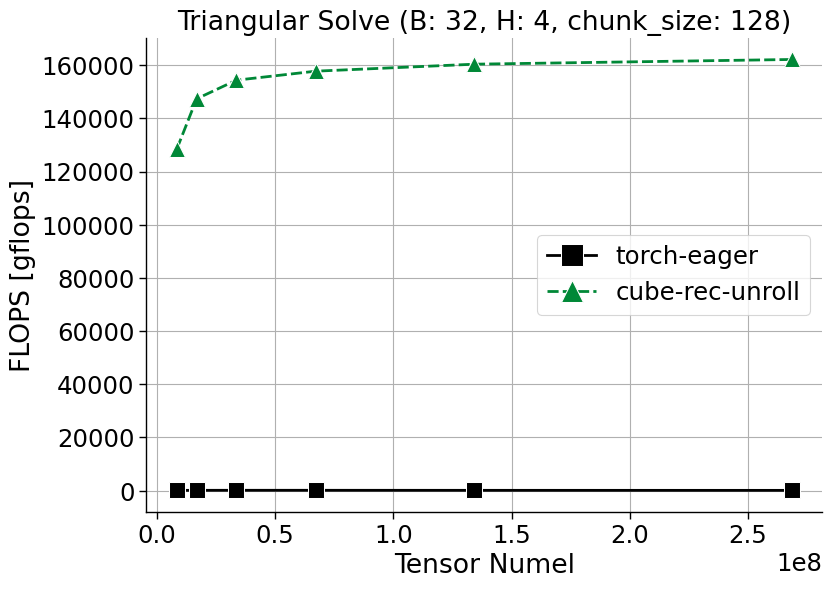

<Figure size 870x627 with 0 Axes>

In [18]:
ax = sns.lineplot(data=df, x='size', y='gflops', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Triangular Solve (B: {B}, H: {H}, chunk_size: {chunk_size})")
ax.set_xlabel("Tensor Numel")
ax.set_ylabel("FLOPS [gflops]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/tri_inv_gelemps.png")
plt.show()
plt.clf()